# 01 — Exploratory Data Analysis (EDA)

**Project:** AI-Based Cybersecurity Threat Detection Using Machine Learning Techniques
**Datasets:** NSL-KDD and CICIDS2017

This notebook is the first place we look at our data before building any model.
Think of it as "meeting the data": what is in it, how balanced is it, are there
missing values, and which features behave like each other?

By the end it writes `reports/eda_report.md` automatically, so the report is
always in sync with the code that produced it.

**How to run:** open this notebook in Jupyter / VS Code and run all cells
(`Kernel > Restart & Run All`). Everything is computed from the raw files — no
numbers are hard-coded.

In [1]:
# --- Setup -----------------------------------------------------------------
# Make sure Python can find the project's own code (src/) from anywhere.
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent          # keep walking up until we find the project root
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import loader as L          # our own loader (Phase 1)
from src.utils import config as C         # paths + label maps

# A folder to hold every chart this notebook produces.
FIGDIR = C.REPORTS_DIR / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")          # consistent, clean look for all plots
pd.set_option("display.max_columns", 60)
print("Setup complete. Saving figures to:", FIGDIR)

Setup complete. Saving figures to: D:\Cyber threat Detection\reports\figures


## 1. NSL-KDD

NSL-KDD is the improved version of the old **KDD Cup 1999** dataset (DARPA
1998 simulation). It contains **41 features** per network connection (protocol,
service, bytes sent/received, flags, ...) and a label. We load it with our
loader, which already:
  * names the 41 columns,
  * drops the "difficulty" score,
  * converts numbers out of text,
  * adds `attack_category` (Normal / DoS / Probe / R2L / U2R) and `is_attack`.

In [2]:
# Load both official NSL-KDD splits.
NSL_TRAIN = L.load_nsl_kdd("train")
NSL_TEST  = L.load_nsl_kdd("test")

print("Train shape (rows, cols):", NSL_TRAIN.shape)
print("Test  shape (rows, cols):", NSL_TEST.shape)
print()
print("Columns of the common schema:")
print(list(NSL_TRAIN.columns)[-5:])

Train shape (rows, cols): (125973, 45)
Test  shape (rows, cols): (22544, 45)

Columns of the common schema:
['dst_host_srv_rerror_rate', 'attack_type', 'attack_category', 'is_attack', 'source']


In [3]:
# --- Class distribution: is traffic normal or an attack? ---------------
print("=== is_attack (0 = normal, 1 = attack) — TRAIN ===")
print(NSL_TRAIN[C.IS_ATTACK_COL].value_counts().sort_index().to_string())
print()
print("=== coarse attack category — TRAIN ===")
cat_counts = NSL_TRAIN[C.CATEGORY_COL].value_counts().sort_values(ascending=False)
print(cat_counts.to_string())
print()
print("=== coarse attack category — TEST ===")
print(NSL_TEST[C.CATEGORY_COL].value_counts().sort_values(ascending=False).to_string())

# How imbalanced is it?  % of rows that are normal traffic.
nsl_normal = cat_counts.get("Normal", 0)
nsl_normal_pct = 100.0 * nsl_normal / len(NSL_TRAIN)
print()
print(f"Normal traffic is {nsl_normal_pct:.1f}% of the TRAIN set.")
print("-> A model that ALWAYS answers 'Normal' would score", f"{nsl_normal_pct:.1f}%",
      "accuracy and detect ZERO attacks.")

=== is_attack (0 = normal, 1 = attack) — TRAIN ===
is_attack
0    67343
1    58630

=== coarse attack category — TRAIN ===
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52

=== coarse attack category — TEST ===
attack_category
Normal    9711
DoS       7458
R2L       2887
Probe     2421
U2R         67

Normal traffic is 53.5% of the TRAIN set.
-> A model that ALWAYS answers 'Normal' would score 53.5% accuracy and detect ZERO attacks.


In [4]:
# --- The rare classes matter: how many rows per specific attack? ---------
top_types = NSL_TRAIN[C.TYPE_COL].value_counts().head(15)
print("Top 15 specific attack types in TRAIN:")
print(top_types.to_string())
print()
print("Rarest classes in TRAIN (the ones SMOTE will have to help with later):")
rare = NSL_TRAIN[C.TYPE_COL].value_counts().tail(8)
print(rare.to_string())

Top 15 specific attack types in TRAIN:
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18

Rarest classes in TRAIN (the ones SMOTE will have to help with later):
attack_type
imap          11
rootkit       10
loadmodule     9
ftp_write      8
multihop       7
phf            4
perl           3
spy            2


In [5]:
# --- Missing values ------------------------------------------------------
# A "missing value" is a blank cell.  Models hate blanks, so we count them now.
train_missing = NSL_TRAIN.isna().sum()
test_missing  = NSL_TEST.isna().sum()
print("Train: missing cells per column (only non-zero shown):")
print(train_missing[train_missing > 0].to_string() or "  (none!)")
print()
print("Test:  missing cells per column (only non-zero shown):")
print(test_missing[test_missing > 0].to_string() or "  (none!)")

Train: missing cells per column (only non-zero shown):
Series([], )

Test:  missing cells per column (only non-zero shown):
Series([], )


In [6]:
# --- Basic statistics for a few numeric features --------------------------
# describe() gives count / mean / std / min / max for numeric columns.
num_cols = [c for c in C.NSL_KDD_FEATURES if c not in C.NSL_KDD_CATEGORICAL_FEATURES]
stats = NSL_TRAIN[num_cols].describe().T
print("Numeric features in NSL-KDD:", len(num_cols))
print(stats[["mean", "std", "min", "max"]].head(12).to_string())

# Features with zero variance (= constant, give a model no information).
zero_var = [c for c in num_cols if NSL_TRAIN[c].nunique() <= 1]
print()
print("Constant (zero-variance) features in train:", zero_var or "none")

Numeric features in NSL-KDD: 38
                           mean           std  min           max
duration             287.144650  2.604515e+03  0.0  4.290800e+04
src_bytes          45566.743000  5.870331e+06  0.0  1.379964e+09
dst_bytes          19779.114421  4.021269e+06  0.0  1.309937e+09
land                   0.000198  1.408607e-02  0.0  1.000000e+00
wrong_fragment         0.022687  2.535300e-01  0.0  3.000000e+00
urgent                 0.000111  1.436603e-02  0.0  3.000000e+00
hot                    0.204409  2.149968e+00  0.0  7.700000e+01
num_failed_logins      0.001222  4.523914e-02  0.0  5.000000e+00
logged_in              0.395736  4.890101e-01  0.0  1.000000e+00
num_compromised        0.279250  2.394204e+01  0.0  7.479000e+03
root_shell             0.001342  3.660284e-02  0.0  1.000000e+00
su_attempted           0.001103  4.515438e-02  0.0  2.000000e+00



Constant (zero-variance) features in train: ['num_outbound_cmds']


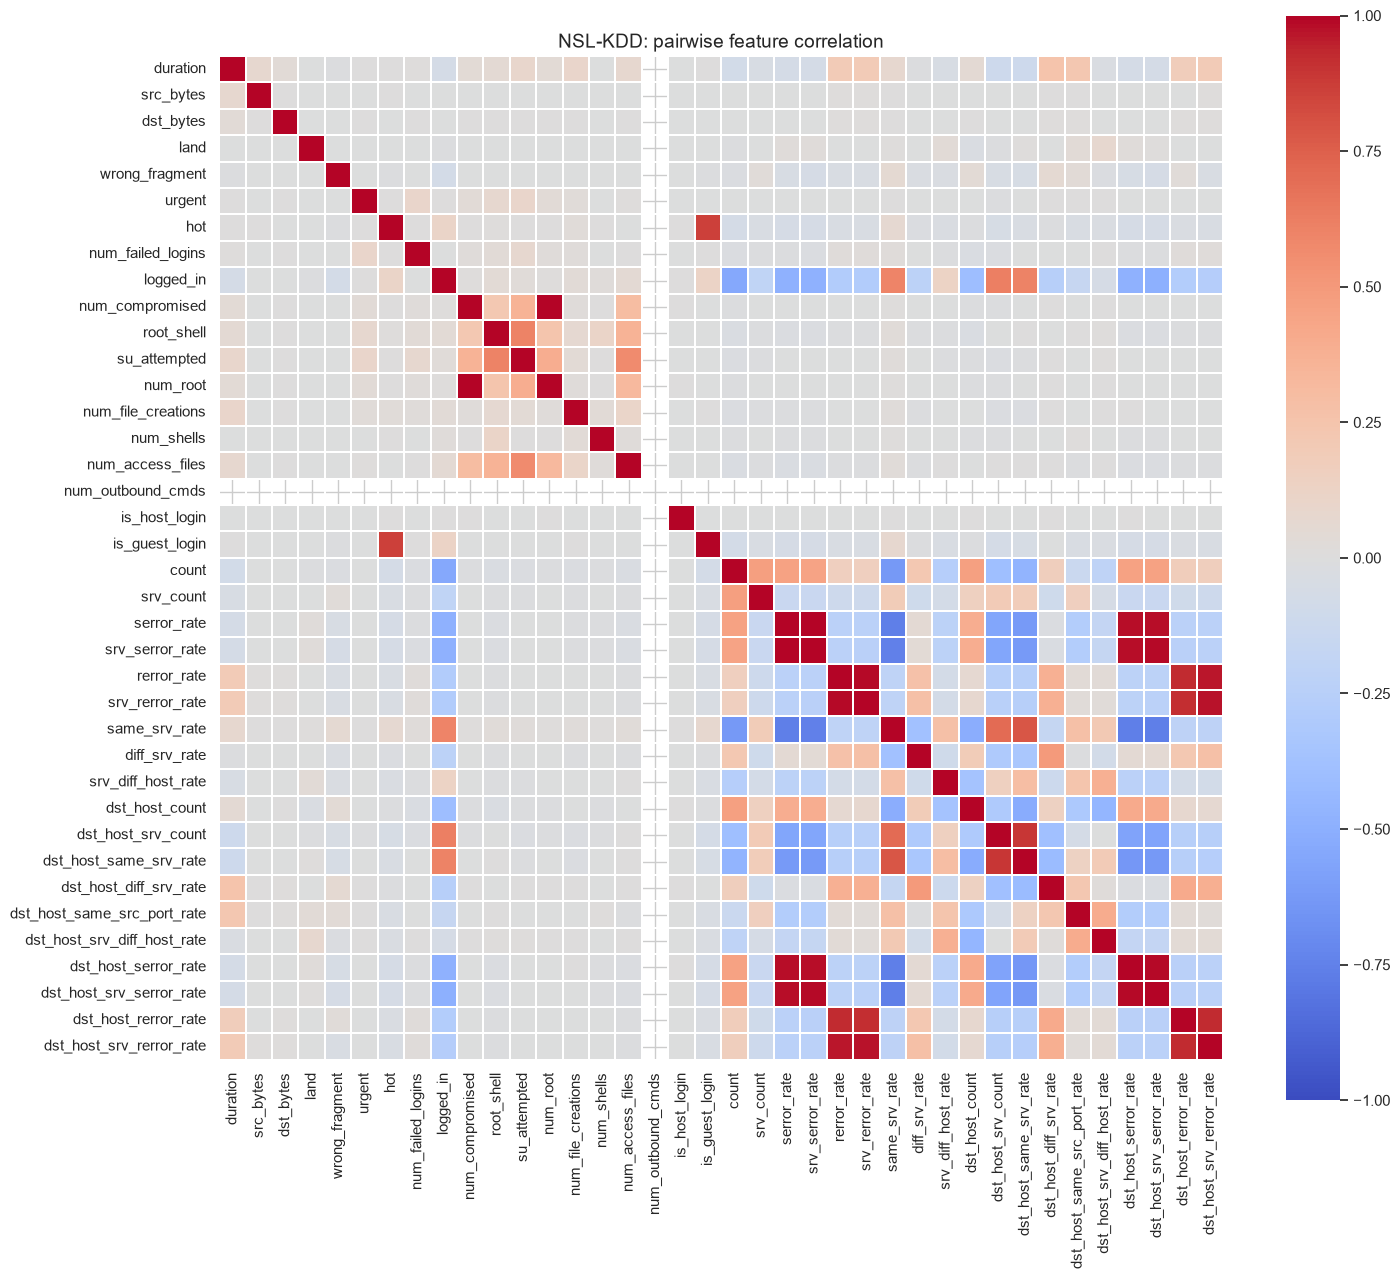

Pairs of features with |correlation| > 0.9: 13
   num_compromised              ~ num_root                      r = +0.999
   serror_rate                  ~ srv_serror_rate               r = +0.993
   serror_rate                  ~ dst_host_serror_rate          r = +0.979
   serror_rate                  ~ dst_host_srv_serror_rate      r = +0.981
   srv_serror_rate              ~ dst_host_serror_rate          r = +0.978
   srv_serror_rate              ~ dst_host_srv_serror_rate      r = +0.986
   rerror_rate                  ~ srv_rerror_rate               r = +0.989
   rerror_rate                  ~ dst_host_rerror_rate          r = +0.927


In [7]:
# --- Feature correlation heatmap ------------------------------------------
# Correlation ~= "do two features move together?".  A heatmap makes clusters
# of redundant features easy to spot (bright red = almost the same feature).
corr_nsl = NSL_TRAIN[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr_nsl, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.2, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("NSL-KDD: pairwise feature correlation", fontsize=14)
fig.tight_layout()
fig.savefig(FIGDIR / "nsl_kdd_correlation.png", dpi=120)
plt.show()

# Count strongly-correlated pairs (|r| > 0.9) — candidates for removal later.
nsl_mat = corr_nsl.abs()
upper = nsl_mat.where(np.triu(np.ones(nsl_mat.shape), k=1).astype(bool))
rows_idx, cols_idx = np.where(upper > 0.9)   # positions of strong pairs
nsl_pairs = [(upper.index[i], upper.columns[j]) for i, j in zip(rows_idx, cols_idx)]
print(f"Pairs of features with |correlation| > 0.9: {len(nsl_pairs)}")
for r, c in nsl_pairs[:8]:
    print(f"   {r:28s} ~ {c:28s}  r = {nsl_mat.loc[r, c]:+.3f}")

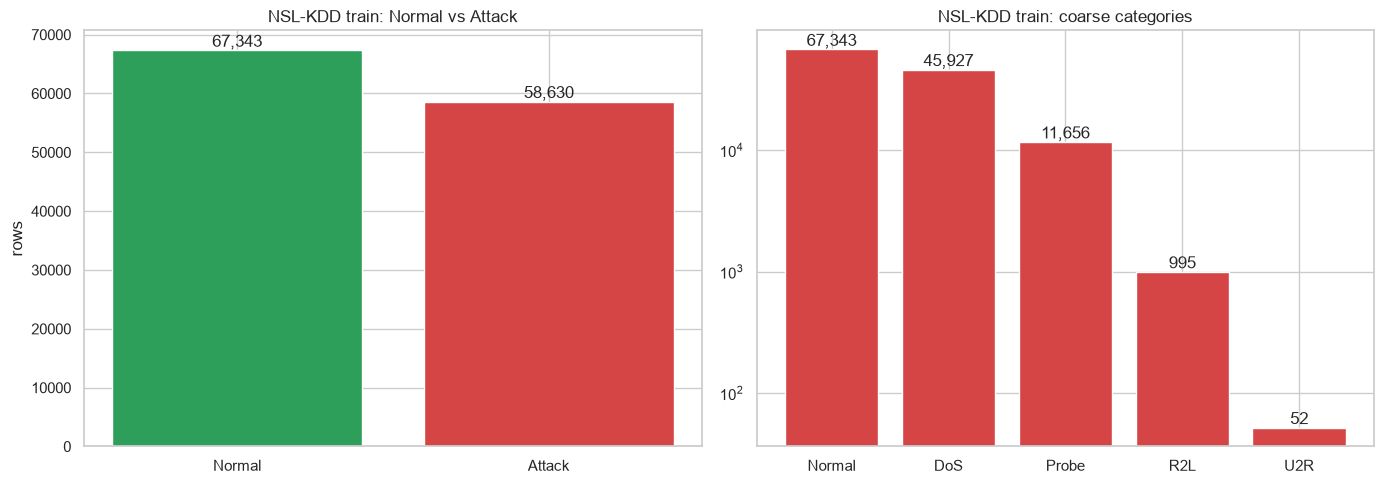

Notice: U2R (52) and R2L (995) are dwarfed by DoS (45,927).
This is the class-imbalance problem this project must handle.


In [8]:
# --- Class distribution plot ----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#2e9e5b", "#d64545"]                      # green = normal, red = attack

is_att = NSL_TRAIN[C.IS_ATTACK_COL].map({0: "Normal", 1: "Attack"}).value_counts()
axes[0].bar(is_att.index, is_att.values, color=colors[:len(is_att)])
axes[0].set_title("NSL-KDD train: Normal vs Attack")
axes[0].set_ylabel("rows")
for i, v in enumerate(is_att.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

cat_order = cat_counts.index
axes[1].bar(cat_order, cat_counts.values, color="#d64545")
axes[1].set_title("NSL-KDD train: coarse categories")
axes[1].set_yscale("log")                            # log scale makes the tiny
for i, v in enumerate(cat_counts.values):            # classes (U2R: 52) visible
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGDIR / "nsl_kdd_class_distribution.png", dpi=120)
plt.show()

print("Notice: U2R (52) and R2L (995) are dwarfed by DoS (45,927).")
print("This is the class-imbalance problem this project must handle.")

## 2. CICIDS2017

CICIDS2017 is a much newer, more realistic dataset (generated by the Canadian
Institute for Cybersecurity in 2017 over 5 days of real background traffic).
It has **78 numeric features** per flow and ~**2.8 million flows** total, so we
read it in **chunks** — the loader hands us one piece at a time and we count
things without ever loading 2.8M rows at once.

In [9]:
# Stream through all 8 daily CSVs and count classes (memory-friendly).
from collections import Counter
cic_cat  = Counter()
cic_type = Counter()
cic_total = 0

for chunk in L.cicids2017_chunks(chunksize=1_000_000):
    cic_total += len(chunk)
    cic_cat.update(chunk[C.CATEGORY_COL].value_counts().to_dict())
    cic_type.update(chunk[C.TYPE_COL].value_counts().to_dict())

print(f"Total CICIDS2017 flows: {cic_total:,}")
print()
print("=== coarse attack category (all flows) ===")
for k, v in cic_cat.most_common():
    print(f"   {k:<15} {v:,}")
print()
print("=== specific attack types ===")
for k, v in cic_type.most_common():
    print(f"   {k:<30} {v:,}")

cic_normal = cic_cat.get("Normal", 0)
cic_normal_pct = 100.0 * cic_normal / cic_total
print()
print(f"Normal traffic is {cic_normal_pct:.1f}% of all flows.")
print("-> Always-Normal baseline accuracy would be", f"{cic_normal_pct:.1f}%,")
print("   while catching NOTHING. (This is exactly the imbalance trap.)")

Total CICIDS2017 flows: 2,830,743

=== coarse attack category (all flows) ===
   Normal          2,273,097
   DoS             252,661
   PortScan        158,930
   DDoS            128,027
   Brute Force     13,835
   Web Attack      2,180
   Botnet          1,966
   Infiltration    36
   Heartbleed      11

=== specific attack types ===
   BENIGN                         2,273,097
   DoS Hulk                       231,073
   PortScan                       158,930
   DDoS                           128,027
   DoS GoldenEye                  10,293
   FTP-Patator                    7,938
   SSH-Patator                    5,897
   DoS slowloris                  5,796
   DoS Slowhttptest               5,499
   Bot                            1,966
   Web Attack - Brute Force       1,507
   Web Attack - XSS               652
   Infiltration                   36
   Web Attack - Sql Injection     21
   Heartbleed                     11

Normal traffic is 80.3% of all flows.
-> Always-Normal basel

In [10]:
# --- A random sample for statistics, missing values & correlation ---------
# ~2% of 2.8M rows = ~56k flows: plenty to characterise the dataset.
CIC_SAMPLE = L.load_cicids2017(sample_frac=0.02)
print("Sample shape (rows, cols):", CIC_SAMPLE.shape)
print()
print("Basic statistics for key numeric features (sample):")
key_feats = ["flow_duration", "total_fwd_packets", "total_length_of_fwd_packets",
             "flow_bytes_s", "packet_length_mean", "destination_port", "average_packet_size"]
print(CIC_SAMPLE[key_feats].describe().T[["mean", "std", "min", "max"]].to_string())

Sample shape (rows, cols): (56614, 82)

Basic statistics for key numeric features (sample):
                                     mean           std  min           max
flow_duration                1.448929e+07  3.330848e+07  0.0  1.200000e+08
total_fwd_packets            5.811884e+00  2.838535e+01  1.0  3.045000e+03
total_length_of_fwd_packets  5.164522e+02  3.364354e+03  0.0  3.432130e+05
flow_bytes_s                          inf           NaN  0.0           inf
packet_length_mean           1.714797e+02  3.059714e+02  0.0  2.433333e+03
destination_port             8.158945e+03  1.838118e+04  0.0  6.553200e+04
average_packet_size          1.915856e+02  3.324992e+02  0.0  2.539130e+03


D:\Cyber threat Detection\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [11]:
# --- Missing values & infinite values in the sample -----------------------
# CICIDS2017 has a known quirk: flows with duration 0 produce Inf (division by
# zero) in the *_bytes_s / *_packets_s rate columns.  We need to know this NOW
# because preprocessing (Phase 2) will have to deal with it.
num_feats = [c for c in CIC_SAMPLE.columns if c not in [C.TYPE_COL, C.CATEGORY_COL, C.IS_ATTACK_COL, C.SOURCE_COL]]
missing = CIC_SAMPLE[num_feats].isna().sum()
inf_cols = {c: int(np.isinf(CIC_SAMPLE[c]).sum()) for c in num_feats if np.isinf(CIC_SAMPLE[c]).sum() > 0}
print(f"Sample size: {len(CIC_SAMPLE):,} rows")
print("NaN missing cells total in sample:", int(missing.sum()))
print("Columns with NaN (top 10):")
print(missing[missing > 0].sort_values(ascending=False).head(10).to_string() or "  (none)")
print()
print("Columns containing Inf (division-by-zero rate columns):")
for k, v in sorted(inf_cols.items(), key=lambda x: -x[1])[:10]:
    print(f"   {k:28s} {v:,}")

Sample size: 56,614 rows
NaN missing cells total in sample: 26
Columns with NaN (top 10):
flow_bytes_s    26

Columns containing Inf (division-by-zero rate columns):
   flow_packets_s               60
   flow_bytes_s                 34


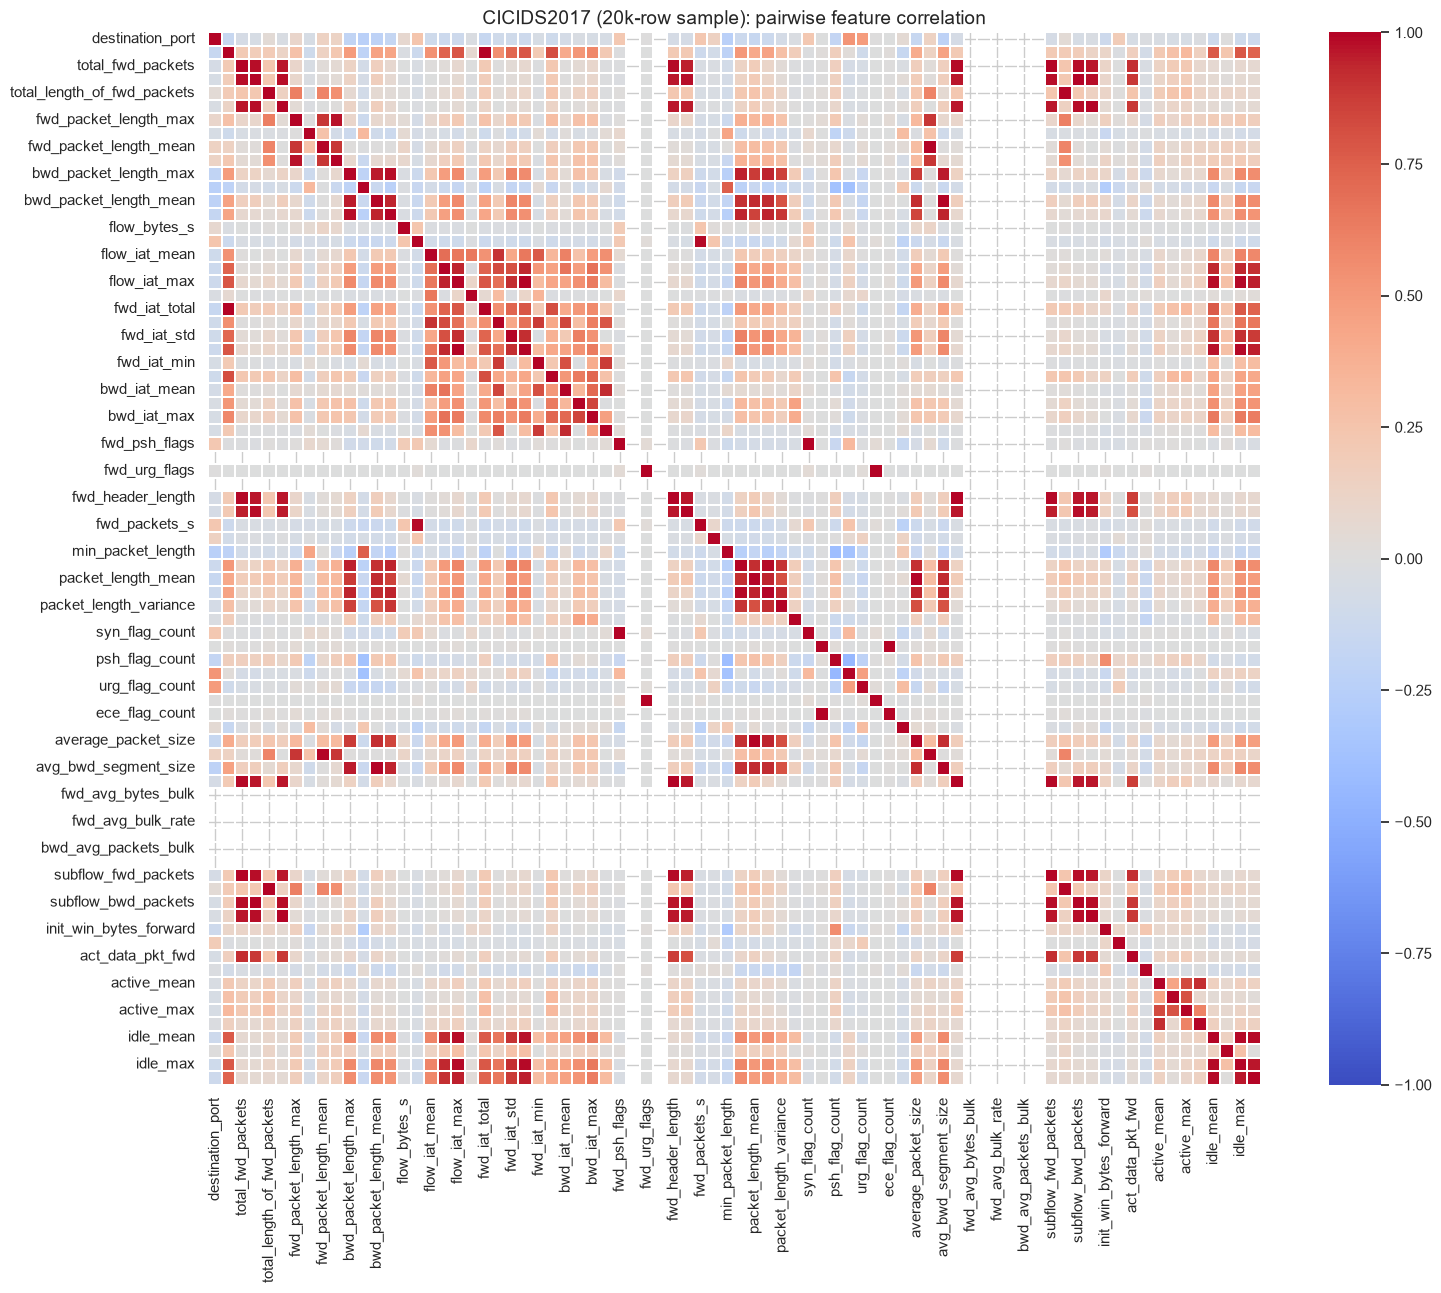

Pairs of features with |correlation| > 0.9: 93
   flow_duration                    ~ fwd_iat_total                     r = +0.998
   total_fwd_packets                ~ total_backward_packets            r = +0.979
   total_fwd_packets                ~ total_length_of_bwd_packets       r = +0.969
   total_fwd_packets                ~ fwd_header_length                 r = +0.985
   total_fwd_packets                ~ bwd_header_length                 r = +0.949
   total_fwd_packets                ~ fwd_header_length_1               r = +0.985
   total_fwd_packets                ~ subflow_fwd_packets               r = +1.000
   total_fwd_packets                ~ subflow_bwd_packets               r = +0.979


In [12]:
# --- Correlation heatmap on the sample ------------------------------------
corr_cic = CIC_SAMPLE[num_feats].sample(n=20_000, random_state=C.RANDOM_STATE).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_cic, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.2, ax=ax)
ax.set_title("CICIDS2017 (20k-row sample): pairwise feature correlation", fontsize=14)
fig.tight_layout()
fig.savefig(FIGDIR / "cicids2017_correlation.png", dpi=120)
plt.show()

cic_mat = corr_cic.abs()
upper = cic_mat.where(np.triu(np.ones(cic_mat.shape), k=1).astype(bool))
rows_idx, cols_idx = np.where(upper > 0.9)
cic_pairs = [(upper.index[i], upper.columns[j]) for i, j in zip(rows_idx, cols_idx)]
print(f"Pairs of features with |correlation| > 0.9: {len(cic_pairs)}")
for r, c in cic_pairs[:8]:
    print(f"   {r:32s} ~ {c:32s}  r = {cic_mat.loc[r, c]:+.3f}")

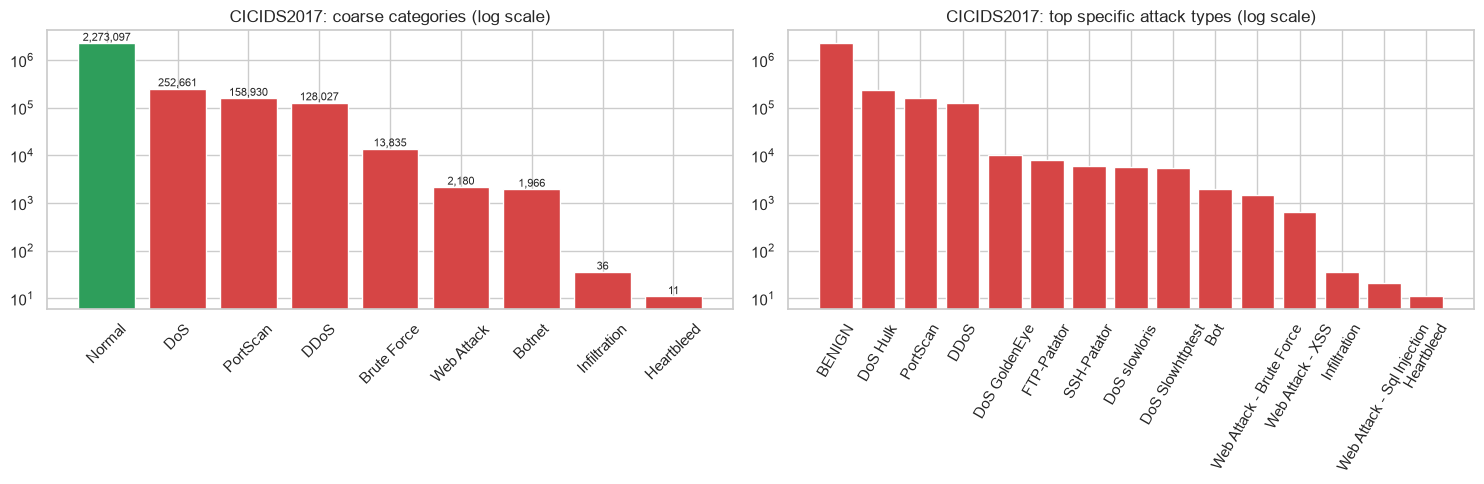

Heartbleed (11) and Infiltration (36) are extremely rare in the raw data,
so any model must not be allowed to simply ignore them.


In [13]:
# --- Class distribution plot ----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cats = pd.Series(cic_cat).sort_values(ascending=False)
colors2 = ["#d64545" if k != "Normal" else "#2e9e5b" for k in cats.index]
axes[0].bar(cats.index, cats.values, color=colors2)
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("CICIDS2017: coarse categories (log scale)")
for i, v in enumerate(cats.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

types = pd.Series(cic_type).sort_values(ascending=False).head(15)
axes[1].bar(types.index, types.values, color="#d64545")
axes[1].tick_params(axis="x", rotation=60)
axes[1].set_yscale("log")
axes[1].set_title("CICIDS2017: top specific attack types (log scale)")
fig.tight_layout()
fig.savefig(FIGDIR / "cicids2017_class_distribution.png", dpi=120)
plt.show()

print("Heartbleed (11) and Infiltration (36) are extremely rare in the raw data,")
print("so any model must not be allowed to simply ignore them.")

## 3. Auto-generated report

The cell below writes `reports/eda_report.md` using the *actual* numbers
computed in this notebook. Re-running this notebook therefore regenerates an
up-to-date report — no hand-typed statistics to drift out of date.

In [14]:
# --- Assemble the report ---------------------------------------------------
nsl_missing_total = int(NSL_TRAIN.isna().sum().sum()) + int(NSL_TEST.isna().sum().sum())
cic_missing_total = int(missing.sum())
cic_sample_rows = len(CIC_SAMPLE)
cic_pairs_count = len(cic_pairs)
nsl_zero_var = zero_var

report = f"""# EDA Report (auto-generated)

*Generated by `notebooks/01_eda.ipynb` on {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}.*

## 1. What the two datasets are

- **NSL-KDD** (2009) — an improved version of the 1999 KDD Cup dataset. It has
  **41 features** per network connection (protocol type, service, bytes sent and
  received, TCP flags, host/count statistics, ...). Train set: {len(NSL_TRAIN):,} rows,
  test set: {len(NSL_TEST):,} rows.
- **CICIDS2017** (2017) — {cic_total:,} network flows with **78 numeric features** each,
  captured by the Canadian Institute for Cybersecurity over five days of realistic
  traffic. It is read in chunks because of its size.

## 2. Class distribution and why imbalance matters

**NSL-KDD (train):** normal = {nsl_normal:,} rows ({nsl_normal_pct:.1f}%); attacks = {len(NSL_TRAIN) - nsl_normal:,} rows ({100 - nsl_normal_pct:.1f}%).
By coarse category:

| Category | Rows |
|----------|-----:|
"""
for k, v in cat_counts.items():
    report += f"| {k} | {v:,} |\n"
report += f"""
The rare classes **U2R ({int(cat_counts.get('U2R', 0)):,} rows)** and **R2L ({int(cat_counts.get('R2L', 0)):,} rows)**
are dwarfed by **DoS ({int(cat_counts.get('DoS', 0)):,} rows)**.

**CICIDS2017 (all flows):** normal = {cic_normal:,} ({cic_normal_pct:.1f}%); attacks = {cic_total - cic_normal:,} ({100 - cic_normal_pct:.1f}%).

| Category | Rows |
|----------|-----:|
"""
for k, v in cic_cat.most_common():
    report += f"| {k} | {v:,} |\n"
report += f"""
> **Why this matters:** a naive model that *always* answers "normal" would score
> **{nsl_normal_pct:.1f}%** accuracy on NSL-KDD and **{cic_normal_pct:.1f}%** on
> CICIDS2017 without detecting a single attack. High accuracy can therefore be
> completely misleading on imbalanced data. That is why this project:
>   1. reports **precision / recall / F1 / AUC-ROC** as well as accuracy,
>   2. applies **SMOTE** to the *training* split only (Phase 2),
>   3. uses **stratified** cross-validation (Phase 3).

## 3. Missing values

- NSL-KDD: **{nsl_missing_total:,}** missing cells across train+test.
- CICIDS2017 sample ({cic_sample_rows:,} rows): **{cic_missing_total:,}** missing cells
  (NaN), plus **{sum(inf_cols.values()):,}** infinite values in the
  division-by-zero rate columns (`flow_bytes_s`, `flow_packets_s`, ...) that occur
  when a flow has duration 0. Phase 2 will replace Inf with NaN and impute with
  the median.

## 4. Correlated / redundant features

- NSL-KDD: **{len(nsl_pairs)}** feature pairs have |correlation| > 0.9. Example pairs:
"""
for r, c in nsl_pairs[:5]:
    report += f"    - `{r}` ~ `{c}` (r = {nsl_mat.loc[r, c]:+.2f})\n"
report += f"""
- CICIDS2017 (20k sample): **{cic_pairs_count}** such pairs.

Highly-correlated features are partially redundant. Removing some of them (via
the correlation / mutual-information / RFE analysis in Phase 2) can cut training
and prediction time with little accuracy loss — directly supporting the
complexity-vs-latency trade-off studied in this project.

## 5. Constant (zero-variance) features

- NSL-KDD: {nsl_zero_var if nsl_zero_var else 'none'}.
- (CICIDS2017 is checked more thoroughly during preprocessing.)

## 6. Take-aways for the next phases

1. Both datasets are heavily imbalanced -> SMOTE + careful metrics (Phase 2).
2. CICIDS2017 has Inf/NaN to clean -> median imputation (Phase 2).
3. Many features are correlated -> feature selection can shrink the models (Phase 2).
4. Model performance must be judged on recall of the rare attack classes, not
   raw accuracy (Phase 4).
"""

# Save the report to reports/eda_report.md
out_path = C.REPORTS_DIR / "eda_report.md"
out_path.write_text(report, encoding="utf-8")
print("Wrote", out_path)
print(report)

Wrote D:\Cyber threat Detection\reports\eda_report.md
# EDA Report (auto-generated)

*Generated by `notebooks/01_eda.ipynb` on 2026-08-14 11:14.*

## 1. What the two datasets are

- **NSL-KDD** (2009) — an improved version of the 1999 KDD Cup dataset. It has
  **41 features** per network connection (protocol type, service, bytes sent and
  received, TCP flags, host/count statistics, ...). Train set: 125,973 rows,
  test set: 22,544 rows.
- **CICIDS2017** (2017) — 2,830,743 network flows with **78 numeric features** each,
  captured by the Canadian Institute for Cybersecurity over five days of realistic
  traffic. It is read in chunks because of its size.

## 2. Class distribution and why imbalance matters

**NSL-KDD (train):** normal = 67,343 rows (53.5%); attacks = 58,630 rows (46.5%).
By coarse category:

| Category | Rows |
|----------|-----:|
| Normal | 67,343 |
| DoS | 45,927 |
| Probe | 11,656 |
| R2L | 995 |
| U2R | 52 |

The rare classes **U2R (52 rows)** and **R2L (995 rows)**

## Summary

* NSL-KDD: 41 features, 126k train / 22.5k test rows, moderate imbalance
  (53.5% normal).
* CICIDS2017: 78 features, 2.83M flows, strong imbalance (80.3% normal; some
  classes have only a handful of rows — Heartbleed 11, Infiltration 36).
* Missing values: essentially none in NSL-KDD; CICIDS2017 has Inf/NaN in rate
  columns that need cleaning.
* Many features are strongly correlated in both datasets, which Phase 2's
  feature-selection step will exploit.

Next: **Phase 2 — Preprocessing & Feature Engineering** (imputation, scaling,
one-hot encoding, SMOTE, and the three feature-selection methods).